# LangGraph를 이용한 Corrective RAG


## Vanilla RAG의 구조
- Query 입력 → Retriever가 문서 검색 → LLM이 문서+질문을 기반으로 답변 생성
- 매우 직관적이고 간단한 파이프라인이라 초기에 많이 쓰였음.

### Vanilla RAG의 단점

1. 검색 오류 전파 (Garbage In → Garbage Out)
    > Retriever가 관련 없는 문서를 가져오면, → LLM이 그것을 사실처럼 써버림 → 잘못된 답변(hallucination) 발생

2. 관련 없는 문서 포함 → 답변 품질 저하
    - Retrieval에서 top-k 문서를 무조건 넘기기 때문에
    - 질문과 무관한 문서도 context에 들어감
    - LLM이 혼란을 느끼거나 엉뚱한 출처를 인용할 수 있음

3. Retriever 신뢰성 부족
    - 벡터 검색(semantic search)은 항상 정확하지 않음
    - 오타, 다의어, 추상적 개념 → 검색 실패 가능

4. 비효율성
    - Retriever가 항상 문서를 가져오도록 설계되어 있음
    - 질문이 아주 단순한 경우에도 불필요하게 retrieval이 발생 → 비용 증가

5. 출처 신뢰성 문제
    - LLM은 retrieval 결과를 무조건 신뢰하는 경향이 있어
    - 출처가 부정확하거나 잘못된 정보를 포함해도 검증 없이 사용

## Corrective RAG (CRAG)
핵심 아이디어: 잘못된 retrieval 결과(irrelevant docs)를 그대로 쓰지 않고, LLM이 retrieval quality를 판단하고 수정한다.

### 구조
1. Retriever가 문서를 가져옴
2. LLM(or 별도 classifier)이 해당 문서가 질문과 관련 있는지 판단 (irrelevant이면 버림)
3. 필요시 다시 검색하거나, LLM이 자체 knowledge 기반으로 보완

### 장단점
- 장점
    - 잘못된 검색(garbage in → garbage out) 문제를 줄임
    - 쓸데없는 문서를 줄여 hallucination 위험 감소
- 단점
    - 분류 단계를 거쳐서 latency 증가 가능
    - retriever와 LLM 사이의 "판단 기준" 튜닝 필요- 

## 환경 설정 및 라이브러리 준비

LangGraph와 Chroma DB를 활용한 Corrective RAG를 구현하기 위한 환경을 설정하겠습니다.


In [1]:
# %pip install langchain==0.3.26 langchain-community==0.3.27 langchain-openai==0.3.8 langgraph==0.2.61 chromadb==1.1.0 tavily-python


In [2]:
import warnings
warnings.filterwarnings("ignore")

### API 키 설정
- [OpenAI API 키](https://platform.openai.com/api-keys)
- [Tavily API 키](https://tavily.com/) - 웹 검색용

In [ ]:
import os

# API 키 설정
os.environ["OPENAI_API_KEY"] = "sk-your-openai-api-key"

# Tavily API 키 설정 (웹 검색용)
# https://tavily.com/ 에서 무료 API 키를 받을 수 있습니다.
os.environ["TAVILY_API_KEY"] = "tvly-dev-your-tavily-api-key"

# API 키 확인
openai_key = os.getenv("OPENAI_API_KEY")
tavily_key = os.getenv("TAVILY_API_KEY")

if openai_key:
    print("OpenAI API 키가 설정되었습니다. (GPT 모델 사용)")
else:
    print("OpenAI API 키가 없습니다.")

if tavily_key:
    print("Tavily API 키가 설정되었습니다. (웹 검색 사용)")
else:
    print("Tavily API 키가 설정되지 않았습니다. 웹 검색 기능이 제한될 수 있습니다.")
    print("   https://tavily.com/ 에서 무료 API 키를 받아 설정해주세요.")

OpenAI API 키가 설정되었습니다. (GPT 모델 사용)
Tavily API 키가 설정되었습니다. (웹 검색 사용)


## Vector DB 구현

### Loader

In [4]:
from langchain_community.document_loaders import TextLoader

DATA_PATH = "./data/"
loader = TextLoader(DATA_PATH+"rag-keywords.txt")

docs = loader.load()
len(docs)

1

### Splitter

In [5]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=60, length_function=len)

split_doc1 = text_splitter.split_documents(docs)
len(split_doc1)

11

### Embeddings

In [6]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

### Vector DB

In [7]:
from langchain_community.vectorstores import Chroma

vectorstore = Chroma.from_documents(
    documents=split_doc1, # 문서 리스트
    embedding=embeddings, # 임베딩 함수
    collection_name="rag_keywords", # 컬렉션 이름
    persist_directory="./chroma_rag_keywords" # 영구 저장 경로
)

print("파일이 Chroma VectorStore에 저장되었습니다.")

파일이 Chroma VectorStore에 저장되었습니다.


## Corrective RAG 워크플로우 노드 구현

### LangGraph 상태 정의

In [ ]:
from typing_extensions import TypedDict
from typing import List, Dict, Any 

class State(TypedDict):
    # 사용자 입력 
    question: str 

    # vectordb & web search
    contents: List[str]      # 사용자 질문에 대한 유사한 데이터들
    sources: List[Dict[str, Any]]   # 유사한 데이터들의 메타정보(출처 등)

    # vectordb의 결과 평가 
    evaluation_result: str          # yes / no 
    evaluation_score: float         # 평가 점수 
    evaluation_detail: str          # 평가 내용 

    # 질문 재작성 
    rewritten_question: str          # 재작성된 질문 

    # 최종 답변 
    answer: str                     # LLM의 최종 답변 
    generation_strategy: str        # 왜/어떻게


### 노드 1: 벡터 검색

In [ ]:
def search_vectordb_node(state: State) -> State:
    """
    벡터 데이터베이스에서 관련 문서를 검색합니다.
    """
    print(f"벡터 검색 노드 실행: '{state['question']}'")
    
    # Chroma DB에서 유사 문서 검색
    docs = vectorstore.similarity_search(state["question"], k=5)
    
    return {
        "contents": [ doc.page_content for doc in docs ],
        "sources": [ doc.metadata for doc in docs ],
        "generation_strategy": "vectordb"
    }


### 노드 2: 검색 품질 평가

In [ ]:
from langchain.prompts import PromptTemplate

def __get_prompt_for_evaluation():
    template = """
    당신은 최고의 평가자입니다.
    사용자의 질문에 대한 답변이 벡터DB의 데이터와 얼마나 일치하는지 평가해주세요.

    출력 형식은  JSON 형식으로 다음과 같습니다.
    {{
        "evaluation_result": "yes" or "no",
        "evaluation_score": 0~100 사이의 숫자,
        "evaluation_detail": "답변이 벡터DB의 데이터와 얼마나 일치하는지 설명"
    }}

    사용자의 질문: {question}
    벡터DB의 데이터: 
    {contents}
    """

    return PromptTemplate.from_template(template=template)


In [ ]:
from langchain_openai import ChatOpenAI 
from dotenv import load_dotenv

load_dotenv()

def get_llm_openai(model_name: str = "gpt-5-nano"):
    
    return ChatOpenAI(
        model=model_name,
    )


In [ ]:
import json 

def evaluation_node(state: State) -> State:
    chain = __get_prompt_for_evaluation() | get_llm_openai()

    contents = "\n".join(state["contents"])
    result = chain.invoke({
        "question": state["question"],
        "contents": contents
    })

    json_result = json.loads(result.content)
    return {
        "evaluation_result": json_result["evaluation_result"],
        "evaluation_score": json_result["evaluation_score"],
        "evaluation_detail": json_result["evaluation_detail"]
    }

### 노드 3: 질문 재작성

In [ ]:
from langchain.prompts import PromptTemplate

def __get_prompt_for_rewriting_question():
    template = """
    당신은 최고의 질문 재작성자입니다.
    웹 조회를 위해서 사용자의 질문을 한국어로 명확한 표현을 적용하여 하나의 질문으로 재작성해주세요. 

    사용자의 질문: {question}
    """

    return PromptTemplate.from_template(template=template)


In [ ]:
def rewriting_question_node(state: State) -> State:
    chain = __get_prompt_for_rewriting_question() | get_llm_openai()

    result = chain.invoke({
        "question": state["question"]
    })
    return {
        "rewritten_question": result.content
    }

### 노드 4: 웹 검색

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import load_dotenv

def __get_tavily_search_tool():
    load_dotenv()
    return TavilySearchResults(
        max_results=4,
        search_depth="advanced",
        include_answer=True,
        include_raw_content=True,
        include_images=False,
        include_domains=[
            "wikipedia.org",
            "stackoverflow.com",
            "github.com",
            "huggingface.co"
        ],
    )



In [ ]:
def searching_web_node(state: State) -> State:
    tavily_search = __get_tavily_search_tool()

    results = tavily_search.run(state["rewritten_question"])

    contents = [
        f"제목: {result['title']} & 내용: {result['content']}" for result in results
    ]
    sources = [
        {"source": result['url']} for result in results
    ]
    
    return { 
        "contents": contents,
        "sources": sources,
        "generation_strategy": "web_search"
    }

### 노드 5: 답변 생성

In [ ]:
from langchain.prompts import PromptTemplate

def __get_prompt_for_answer():
    template = """
    당신은 최고의 답변 생성자입니다.
    오직 검색된 문서들만을 참고하여 사용자의 질문에 대한 답변을 작성해주세요!

    사용자의 질문: {question}
    검색된 문서들: 
    {contents}
    """

    return PromptTemplate.from_template(template=template)

In [ ]:
def create_answer_node(state: State) -> State:
    chain = __get_prompt_for_answer() | get_llm_openai()

    contents = "\n".join(state["contents"])
    result = chain.invoke({
        "question": state["question"],
        "contents": contents
    })
    
    return {
        "answer": result.content
    }

### 조건부 라우팅 함수들

In [ ]:
def is_evaluation_yes(state: State) -> str:
    if state["evaluation_result"] == "yes":
        return "create_answer"
    else:
        return "rewriting_question"


## LangGraph 워크플로우 구성

이제 정의한 노드들을 연결하여 완전한 LangGraph 워크플로우를 구성해보겠습니다.


In [ ]:
from langgraph.graph import StateGraph, END, START
from langgraph.checkpoint.memory import MemorySaver

# LangGraph 워크플로우 생성
def create_corrective_rag_graph():
    """
    Corrective RAG를 위한 LangGraph 워크플로우를 생성합니다.
    """
    ###############################
    # StateGraph 생성
    ###############################
    workflow = StateGraph(State)
    
    ###############################
    # 노드 추가 
    ###############################
    workflow.add_node("search_vectordb", search_vectordb_node)
    workflow.add_node("evaluation", evaluation_node)
    workflow.add_node("rewriting_question", rewriting_question_node)
    workflow.add_node("searching_web", searching_web_node)
    workflow.add_node("create_answer", create_answer_node)
    
    ###############################
    # 엣지 추가 
    ###############################
    workflow.add_edge(START, "search_vectordb") 
    workflow.add_edge("search_vectordb", "evaluation")
    workflow.add_conditional_edges(
        "evaluation",
        is_evaluation_yes,
        {
            "create_answer": "create_answer",
            "rewriting_question": "rewriting_question"
        }
    )
    workflow.add_edge("rewriting_question", "searching_web")
    workflow.add_edge("searching_web", "create_answer")
    workflow.add_edge("create_answer", END)
    
    ###############################
    # 컴파일 & (옵션) 메모리 
    ###############################
    app = workflow.compile(checkpointer=MemorySaver())
    
    print("LangGraph Corrective RAG 워크플로우가 생성되었습니다!")
    return app


In [16]:
# 워크플로우 재생성 (검색 실패 로직 수정)
corrective_rag_app = create_corrective_rag_graph()


LangGraph Corrective RAG 워크플로우가 생성되었습니다!


### Corrective RAG 그래프

```
                    시작
                     |
                     v
                    vector_search
                    (벡터 데이터베이스에서 관련 문서를 검색)
                     |
                     v
                    evaluate_quality
                    (LLM 기반 검색 품질 평가)
                     |
                     v
         +-----------+-----------+
         |                       |
         v                       |
  rewrite_question               | 
  (LLM 기반 문서 재작성)         |
         |                       |
         v                       |
  web_search                     |    
  (웹에서 추가 정보를 검색)      |
         |                       |
         +-----+-----+-----------+
                     |
                     v
                    generate_answer
                    (검색된 문서를 기반으로 LLM을 사용하여 최종 답변을 생성)
                     |
                     v
                    종료
```

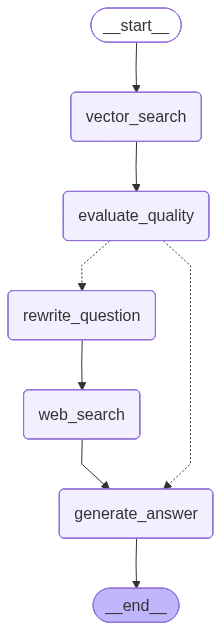

In [17]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            corrective_rag_app.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")


## 실습 예제 및 테스트

이제 완성된 LangGraph Corrective RAG 시스템을 다양한 질문으로 테스트해보겠습니다.


In [ ]:
# 편리한 실행 함수
def run_corrective_rag(question: str, thread_id: str = "demo_thread") -> Dict[str, Any]:
    print(f"Corrective RAG 실행 시작")
    print(f"질문: {question}")
    print("=" * 60)
    
    # 초기 상태 설정
    initial_state = {
        "question": question
    }
    
    # 워크플로우 실행
    config = {"configurable": {"thread_id": thread_id}}
    
    try:
        # 스트리밍 방식으로 실행 과정 확인
        final_state = None
        for step in corrective_rag_app.stream(initial_state, config):
            # 각 단계의 실행 상황을 실시간으로 볼 수 있습니다
            step_info = list(step.keys())[0] if step else "unknown"
            print(f"현재 실행 중: {step_info}")
            final_state = list(step.values())[0] if step else final_state
        
        print("워크플로우 실행 완료!")
        print("=" * 60)
        
        return final_state
        
    except Exception as e:
        print(f"실행 중 오류 발생: {e}")
        return {"error": str(e), "question": question}

In [19]:
# 결과 출력 함수
def display_results(result: Dict[str, Any]):
    """
    실행 결과를 보기 좋게 출력합니다.
    """
    if "error" in result:
        print(f"오류: {result['error']}")
        return
    
    print(f"실행 결과 요약:")
    print("=" * 40)
    print(f"질문: {result.get('question', 'N/A')}")
    print(f"평가 결과: {result.get('evaluation_result', 'N/A')} (점수: {result.get('evaluation_score', 0):.2f})")
    print(f"검색 전략: {result.get('search_strategy', 'N/A')}")
    print(f"사용된 문서 수: {len(result.get('documents', []))}")
    print(f"출처 수: {len(result.get('sources', []))}")
    
    print(f"최종 답변:")
    print("-" * 30)
    print(result.get('answer', '답변을 생성할 수 없습니다.'))
    
    print(f"실행 로그:")
    print("-" * 20)
    for i, message in enumerate(result.get('messages', []), 1):
        print(f"{i}. {message}")


### 실습 예제 1: 높은 관련성 질문 (직접 답변 생성)

In [20]:
print("예상 경로: 벡터 검색 → 평가(yes) → 답변 생성")

result1 = run_corrective_rag("임베딩이란 무엇인가요?")
display_results(result1)


예상 경로: 벡터 검색 → 평가(yes) → 답변 생성
Corrective RAG 실행 시작
질문: 임베딩이란 무엇인가요?
벡터 검색 노드 실행: '임베딩이란 무엇인가요?'
현재 실행 중: vector_search
LLM 기반 검색 품질 평가 노드 실행
라우팅 결정: yes
현재 실행 중: evaluate_quality
LLM 기반 답변 생성 노드 실행
현재 실행 중: generate_answer
워크플로우 실행 완료!
실행 결과 요약:
질문: 임베딩이란 무엇인가요?
평가 결과: yes (점수: 0.92)
검색 전략: vector
사용된 문서 수: 5
출처 수: 5
최종 답변:
------------------------------
'임베딩이란 무엇인가요?'에 대한 답변:

1. 핵심 답변
- 임베딩은 텍스트 데이터(예: 단어나 문장)를 저차원의 연속적인 벡터로 변환하는 과정으로, 이를 통해 컴퓨터가 텍스트를 이해하고 처리할 수 있게 합니다. 예시: "사과"를 [0.65, -0.23, 0.17] 같은 벡터로 표현합니다.

2. 필요한 경우 관련된 세부 정보
- 연관 키워드: 자연어 처리, 벡터화, 딥러닝

검색 전략: 벡터 데이터베이스 검색
출처 정보:
• 벡터DB: ./data/rag-keywords.txt (순위: 1)
• 벡터DB: ./data/rag-keywords.txt (순위: 2)
• 벡터DB: ./data/rag-keywords.txt (순위: 3)
실행 로그:
--------------------
1. content='벡터 검색 완료: 5개 문서 발견' additional_kwargs={} response_metadata={} id='fcbf37b7-190c-450e-b3e7-8c6f51d576ff'
2. content='벡터 검색 완료: 5개 문서 발견' additional_kwargs={} response_metadata={} id='5cd9baff-1f28-4f30-983f-e3128faed061'
3. content='평가 결과: yes

### 실습 예제 2: 낮은 관련성 질문 (웹 검색 후 답변 생성)

In [21]:
### 웹 검색 출처 테스트

print("수정된 웹 검색 기능 테스트")
print("예상 경로: 벡터 검색 → 평가(no) → 질문 재작성 → 웹 검색 → 답변 생성")

result_web_test = run_corrective_rag("삼성전자 주가 어때?")
display_results(result_web_test)


수정된 웹 검색 기능 테스트
예상 경로: 벡터 검색 → 평가(no) → 질문 재작성 → 웹 검색 → 답변 생성
Corrective RAG 실행 시작
질문: 삼성전자 주가 어때?
벡터 검색 노드 실행: '삼성전자 주가 어때?'
현재 실행 중: vector_search
LLM 기반 검색 품질 평가 노드 실행
라우팅 결정: no
현재 실행 중: evaluate_quality
LLM 기반 문서 재작성 노드 실행
현재 실행 중: rewrite_question
웹 검색 노드 실행 (Tavily Search)


/var/folders/tv/05qbcb8954z9x1yvqv_kr2t80000gn/T/ipykernel_46637/58809085.py:13: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  web_search = TavilySearchResults(


현재 실행 중: web_search
LLM 기반 답변 생성 노드 실행
현재 실행 중: generate_answer
워크플로우 실행 완료!
실행 결과 요약:
질문: 삼성전자 주가 어때?
평가 결과: no (점수: 0.05)
검색 전략: web
사용된 문서 수: 2
출처 수: 2
최종 답변:
------------------------------
'삼성전자 주가 어때?'에 대한 답변:

1. 핵심 답변
- 제공된 문서에는 삼성전자 주가의 현재 가격 정보가 포함되어 있지 않아 답변해 드릴 수 없습니다.

2. 필요한 경우 관련된 세부 정보
- 문서 1: 삼성전자의 목표주가를 묻는 예시가 있지만 구체적인 수치나 최신 가격은 제시되지 않습니다.
- 문서 2: 시장가 주문의 동작 원리 등 주식 거래에 대한 일반 설명이 담겨 있지만 주가 정보는 포함되어 있지 않습니다.

검색 전략: 웹 검색 결합
출처 정보:
• 웹검색: hngyb/Finance-QA: 금융어: 한국어 사전 학습 언어 모델 ... - https://github.com/hngyb/Finance-QA (순위: 1) (점수: 0.34)
• 웹검색: 주식 공부 - https://gist.github.com/Curookie/acad8f83e8c456986808c9eb08c9036d (순위: 2) (점수: 0.15)
실행 로그:
--------------------
1. content='벡터 검색 완료: 5개 문서 발견' additional_kwargs={} response_metadata={} id='fcbf37b7-190c-450e-b3e7-8c6f51d576ff'
2. content='벡터 검색 완료: 5개 문서 발견' additional_kwargs={} response_metadata={} id='5cd9baff-1f28-4f30-983f-e3128faed061'
3. content='평가 결과: yes (점수: 0.92)' additional_kwargs={} response_metadata={} id='

### 실습 예제 3: 검색 실패 시 처리 테스트 

In [22]:
### 검색 실패 시 처리 테스트 (수정된 로직)

print("검색 실패 시 '알 수 없다' 답변 및 출처 생략 테스트")
print("예상: 벡터 검색 → 평가(no) → 질문 재작성 → 웹 검색 실패 → '알 수 없다' 답변 (출처 없음)")

result_fail_test_fixed = run_corrective_rag("화성에서 살고 있는 외계인의 일상생활")
display_results(result_fail_test_fixed)


검색 실패 시 '알 수 없다' 답변 및 출처 생략 테스트
예상: 벡터 검색 → 평가(no) → 질문 재작성 → 웹 검색 실패 → '알 수 없다' 답변 (출처 없음)
Corrective RAG 실행 시작
질문: 화성에서 살고 있는 외계인의 일상생활
벡터 검색 노드 실행: '화성에서 살고 있는 외계인의 일상생활'
현재 실행 중: vector_search
LLM 기반 검색 품질 평가 노드 실행
라우팅 결정: no
현재 실행 중: evaluate_quality
LLM 기반 문서 재작성 노드 실행
현재 실행 중: rewrite_question
웹 검색 노드 실행 (Tavily Search)
웹 검색 결과가 없습니다.
현재 실행 중: web_search
LLM 기반 답변 생성 노드 실행
현재 실행 중: generate_answer
워크플로우 실행 완료!
실행 결과 요약:
질문: 화성에서 살고 있는 외계인의 일상생활
평가 결과: no (점수: 0.00)
검색 전략: web_failed
사용된 문서 수: 0
출처 수: 0
최종 답변:
------------------------------
'화성에서 살고 있는 외계인의 일상생활'에 대한 답변:

죄송합니다. 해당 질문에 대한 정보를 찾을 수 없어 답변드릴 수 없습니다.
실행 로그:
--------------------
1. content='벡터 검색 완료: 5개 문서 발견' additional_kwargs={} response_metadata={} id='fcbf37b7-190c-450e-b3e7-8c6f51d576ff'
2. content='벡터 검색 완료: 5개 문서 발견' additional_kwargs={} response_metadata={} id='5cd9baff-1f28-4f30-983f-e3128faed061'
3. content='평가 결과: yes (점수: 0.92)' additional_kwargs={} response_metadata={} id='873f1584-910e-40df-a3a9-aa482dc9